# 01. EDA — Разведочный анализ данных
Telco Customer Churn | IBM Dataset

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (13, 5)})


## 1. Загрузка данных

In [2]:
from src.data_loader import ensure_raw_data

raw_path = ensure_raw_data()
df = pd.read_csv(raw_path)
print(f"Размер датасета: {df.shape[0]:,} строк  |  {df.shape[1]} признаков")
df.head()


[data_loader] Found existing E:\.PetProjects\Churn Predictions\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv, skipping download.
Размер датасета: 7,043 строк  |  21 признаков


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Базовая информация: типы и пропуски

In [3]:
# TotalCharges хранится как object: ~11 строк с пробелом (tenure == 0)
print("Типы данных:")
print(df.dtypes.to_string())
print()
print("Пропущенные значения:", df.isnull().sum().sum())
blank_tc = (df["TotalCharges"].str.strip() == "").sum()
print(f"Пустые строки в TotalCharges: {blank_tc}  (все при tenure == 0)")


Типы данных:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

Пропущенные значения: 0
Пустые строки в TotalCharges: 11  (все при tenure == 0)


## 3. Целевая переменная — Churn

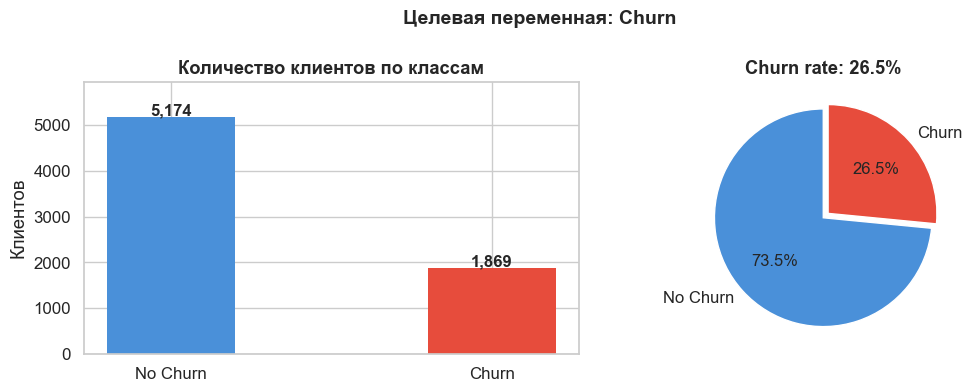

⚠ Дисбаланс классов: churn rate 26.5% — умеренный, требует class_weight при обучении.


In [4]:
counts = df["Churn"].value_counts()
churn_rate = (df["Churn"] == "Yes").mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#4A90D9", "#E74C3C"]
bars = axes[0].bar(["No Churn", "Churn"], counts.values, color=colors, width=0.4, edgecolor="none")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 40, f"{v:,}",
                 ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Количество клиентов по классам", fontweight="bold")
axes[0].set_ylabel("Клиентов")
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values, labels=["No Churn", "Churn"],
            autopct="%1.1f%%", colors=colors, startangle=90, explode=(0, 0.06),
            textprops={"fontsize": 12})
axes[1].set_title(f"Churn rate: {churn_rate:.1%}", fontweight="bold")

plt.suptitle("Целевая переменная: Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"⚠ Дисбаланс классов: churn rate {churn_rate:.1%} — "
      "умеренный, требует class_weight при обучении.")


## 4. Числовые признаки: tenure, MonthlyCharges, TotalCharges

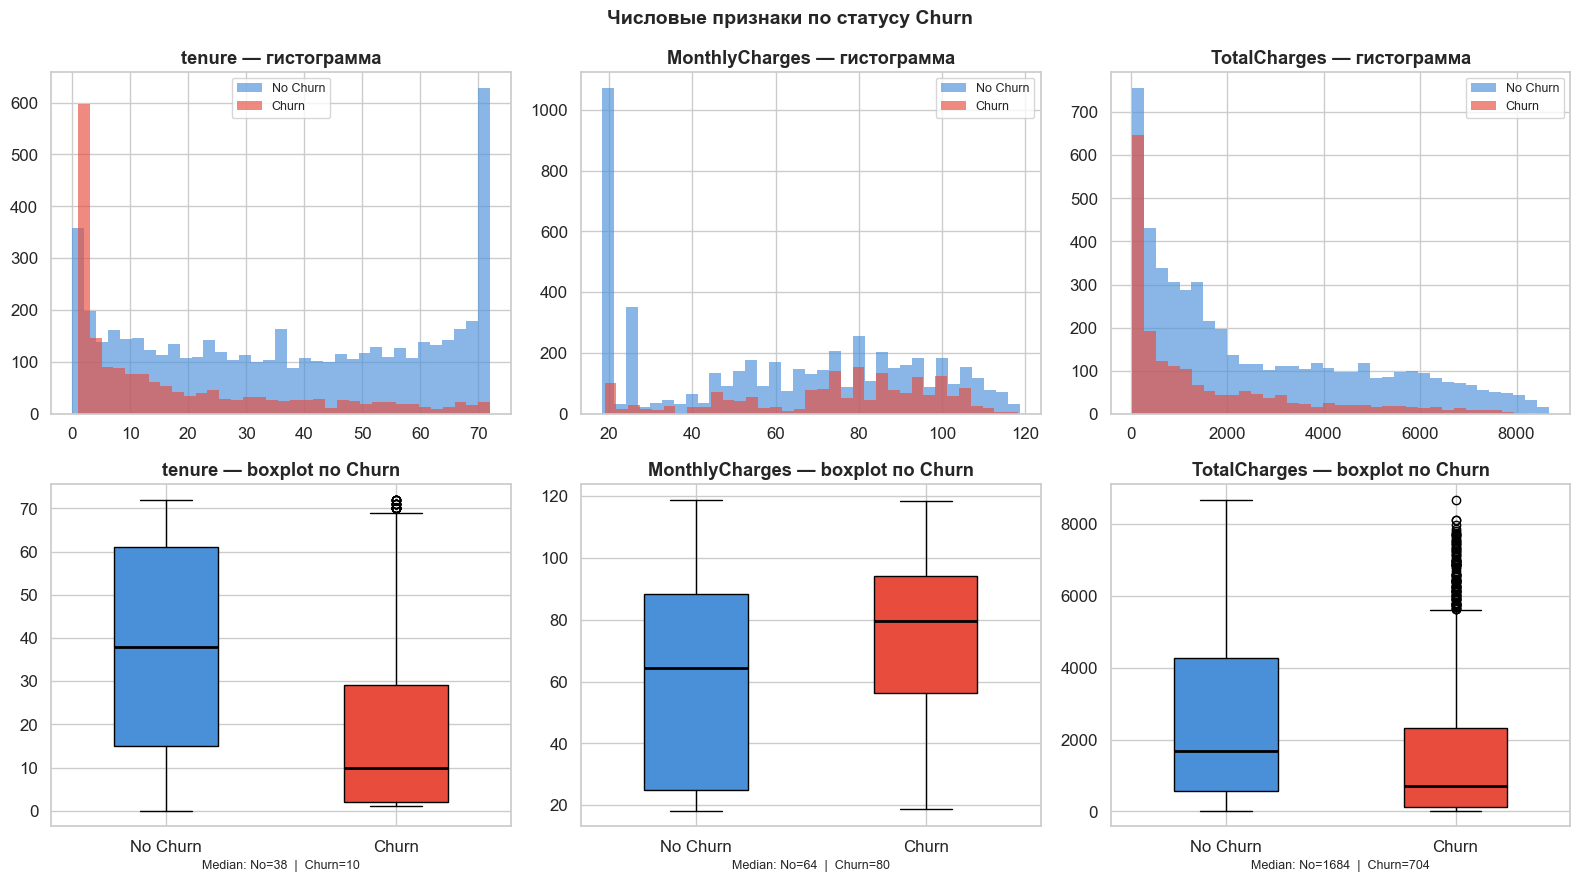

In [5]:
df_p = df.copy()
df_p["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df_p["churned"] = (df["Churn"] == "Yes")

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(num_cols):
    # Гистограмма
    for churned, label, c in [(False, "No Churn", "#4A90D9"), (True, "Churn", "#E74C3C")]:
        d = df_p[df_p["churned"] == churned][col].dropna()
        axes[0, i].hist(d, bins=35, alpha=0.65, label=label, color=c, edgecolor="none")
    axes[0, i].set_title(f"{col} — гистограмма", fontweight="bold")
    axes[0, i].legend(fontsize=9)

    # Boxplot
    data_no  = df_p[~df_p["churned"]][col].dropna()
    data_yes = df_p[ df_p["churned"]][col].dropna()
    bp = axes[1, i].boxplot([data_no, data_yes], labels=["No Churn", "Churn"],
                             patch_artist=True, widths=0.45,
                             medianprops={"color": "black", "linewidth": 2})
    bp["boxes"][0].set_facecolor("#4A90D9")
    bp["boxes"][1].set_facecolor("#E74C3C")
    axes[1, i].set_title(f"{col} — boxplot по Churn", fontweight="bold")
    median_no  = data_no.median()
    median_yes = data_yes.median()
    axes[1, i].set_xlabel(f"Median: No={median_no:.0f}  |  Churn={median_yes:.0f}", fontsize=9)

plt.suptitle("Числовые признаки по статусу Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Категориальные признаки: Churn rate по каждой группе

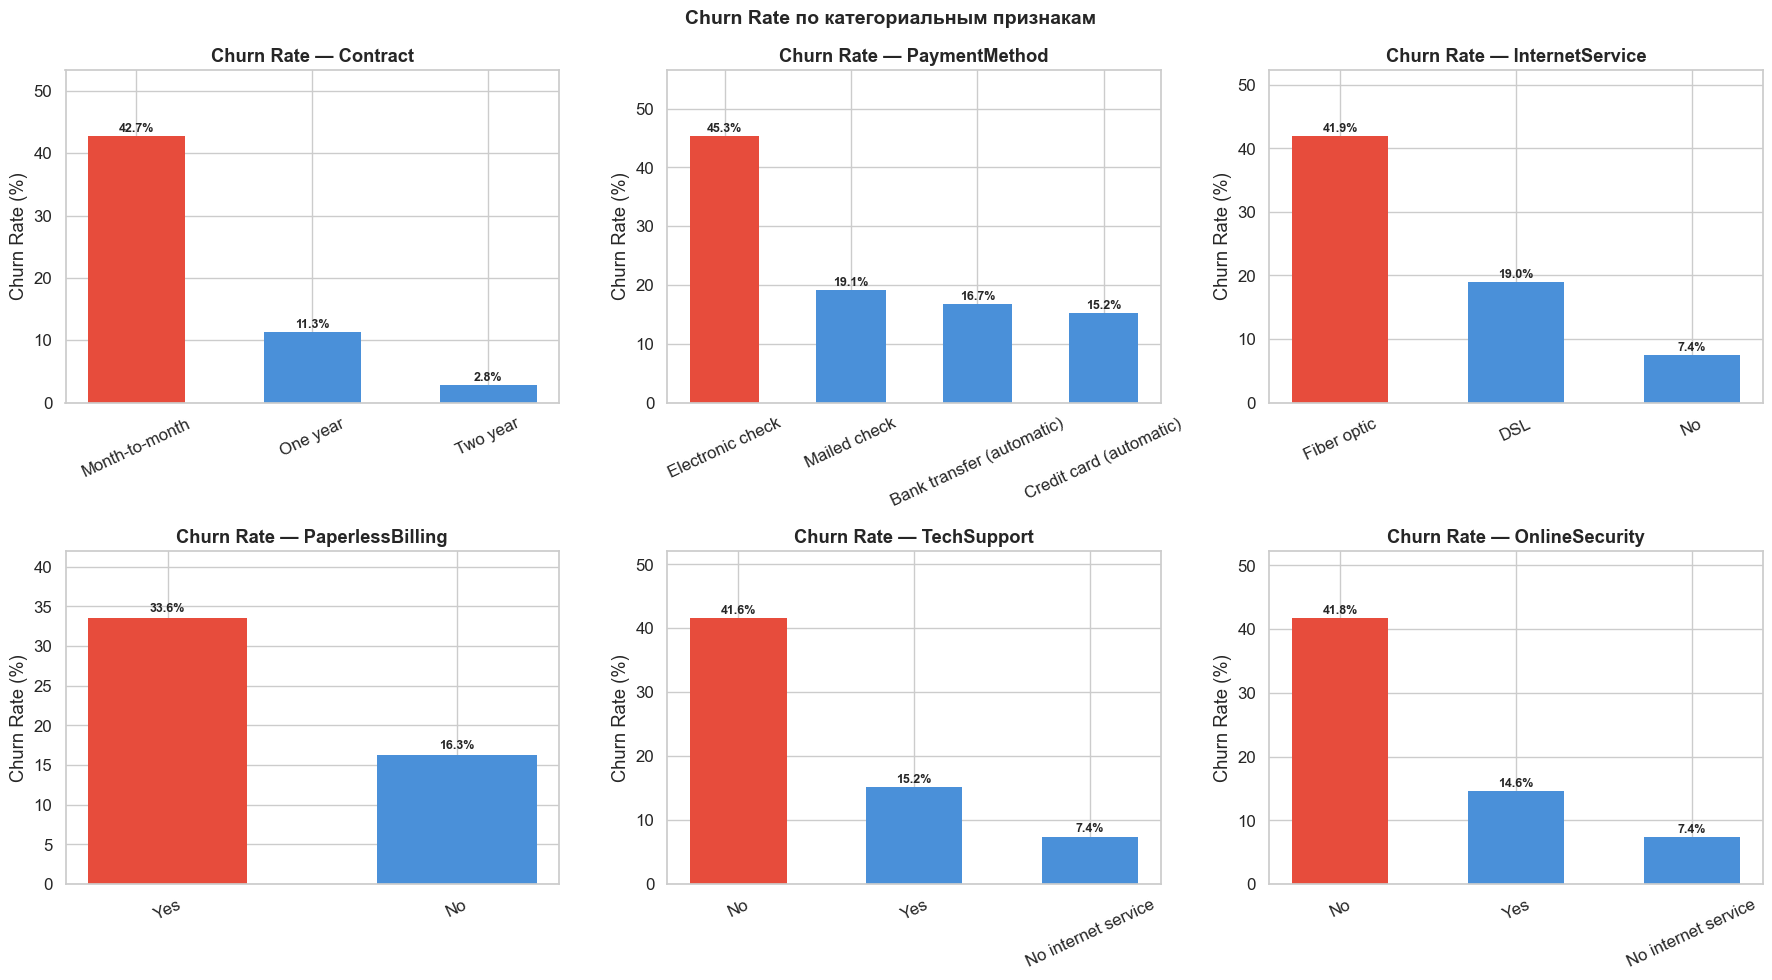

In [6]:
cat_cols = ["Contract", "PaymentMethod", "InternetService",
            "PaperlessBilling", "TechSupport", "OnlineSecurity"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    rates = (df.groupby(col)["Churn"]
               .apply(lambda x: (x == "Yes").mean() * 100)
               .sort_values(ascending=False))
    bar_colors = ["#E74C3C" if v > 30 else "#4A90D9" for v in rates]
    bars = ax.bar(rates.index.astype(str), rates.values,
                  color=bar_colors, edgecolor="none", width=0.55)
    for bar, v in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.7,
                f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"Churn Rate — {col}", fontweight="bold")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, rates.max() * 1.25)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Churn Rate по категориальным признакам", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Матрица корреляций

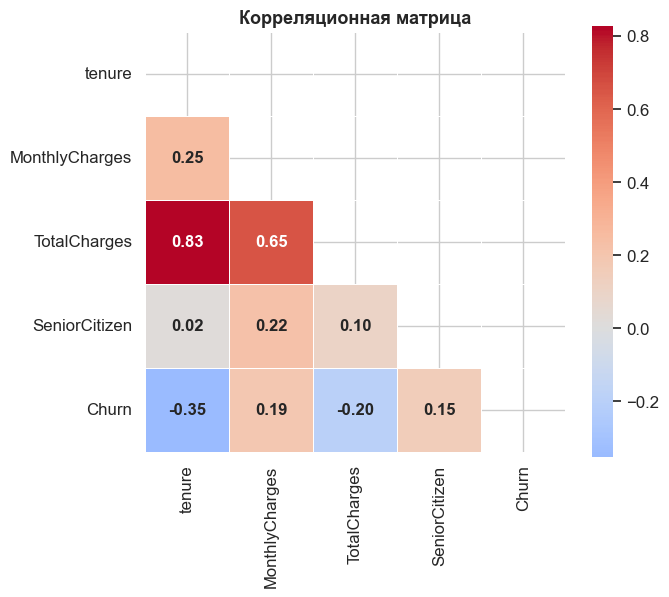

In [7]:
df_corr = pd.DataFrame({
    "tenure":          df["tenure"],
    "MonthlyCharges":  df["MonthlyCharges"],
    "TotalCharges":    pd.to_numeric(df["TotalCharges"], errors="coerce"),
    "SeniorCitizen":   df["SeniorCitizen"],
    "Churn":           (df["Churn"] == "Yes").astype(int),
})

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, square=True,
            linewidths=0.5, annot_kws={"size": 12, "weight": "bold"})
ax.set_title("Корреляционная матрица", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Автоматический профиль (ydata-profiling)

In [8]:
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Telco Churn — EDA Report",
                            minimal=True, explorative=True)
    report_path = Path.cwd() / "eda_report.html"
    profile.to_file(report_path)
    print(f"✅ Интерактивный отчёт сохранён: {report_path.name}")
    print("   Открой в браузере для детального анализа каждого признака.")
except Exception as e:
    print(f"ydata-profiling недоступен: {e}")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 261.73it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Интерактивный отчёт сохранён: eda_report.html
   Открой в браузере для детального анализа каждого признака.


## 8. Ключевые выводы EDA

| Признак | Наблюдение |
|---|---|
| **Churn rate** | 26.5% — умеренный дисбаланс, нужен `class_weight` |
| **Contract** | Month-to-month → churn >40%; Two year → <5% |
| **tenure** | Первые 12 мес. — зона максимального риска |
| **MonthlyCharges** | Churned: median ~75 vs ~61 у retained |
| **InternetService** | Fiber Optic churn вдвое выше DSL |
| **PaymentMethod** | Electronic check → churn ~45% |
| **OnlineSecurity/TechSupport** | «No» → churn в 2-3× выше чем «Yes» |

**Ожидаемые топ-признаки модели:** Contract, tenure, MonthlyCharges,
InternetService, OnlineSecurity, TechSupport, PaymentMethod.
